# Exploratory Data Analysis (EDA): Airline Ticket Prices vs Fuel Costs

This notebook explores the cleaned dataset to uncover trends, relationships, and the impact of macroeconomic factors on airline ticket pricing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')
plt.rcParams['figure.figsize'] = (12, 6)

# Load the dataset
df = pd.read_csv('../data/cleaned_dataset/cleaned_ticket_prices.csv')
df['month'] = pd.to_datetime(df['month'])
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (14355, 32)


,month,conflict_phase,airline,iata_code,country,region,airline_type,route_class,avg_route_km,base_fare_usd,...,yoy_surcharge_change_pct,year,month_num,quarter,is_extreme_fare,fuel_surcharge_ratio,taxes_ratio,base_ratio,crude_jet_ratio,fare_per_km
0,2019-01-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1179.91,...,0.0,2019,1,2019Q1,False,0.0731,0.1171,0.8098,1.1838,0.1714
1,2019-02-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1176.08,...,0.0,2019,2,2019Q1,False,0.0468,0.0933,0.8599,1.2087,0.1609
2,2019-03-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1133.88,...,0.0,2019,3,2019Q1,False,0.0857,0.0876,0.8267,1.1672,0.1614
3,2019-04-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1237.95,...,0.0,2019,4,2019Q2,False,0.0402,0.1155,0.8442,1.1320,0.1725
4,2019-05-01,Pre-Pandemic Baseline,ANA,NH,Japan,Asia,Flag Carrier,Long-Haul,8500,1270.08,...,0.0,2019,5,2019Q2,False,0.0570,0.1119,0.8311,1.1913,0.1798


## 1. Time Series & Trend Analysis
Analyzing how ticket prices and fuel costs evolve over time, especially noting the impact of global conflicts.

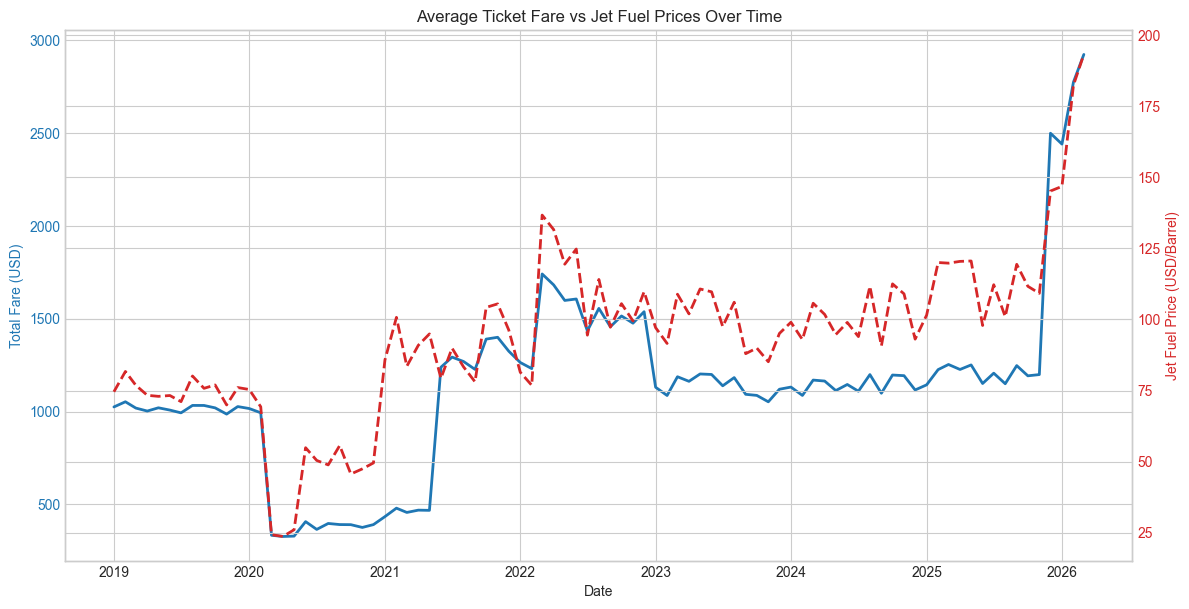

In [2]:
fig, ax1 = plt.subplots()

# Aggregate by month
monthly_trends = df.groupby('month')[['total_fare_usd', 'jet_fuel_usd_barrel', 'fuel_surcharge_usd']].mean().reset_index()

ax1.set_xlabel('Date')
ax1.set_ylabel('Total Fare (USD)', color='tab:blue')
ax1.plot(monthly_trends['month'], monthly_trends['total_fare_usd'], color='tab:blue', label='Avg Total Fare', linewidth=2)
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()  
ax2.set_ylabel('Jet Fuel Price (USD/Barrel)', color='tab:red')  
ax2.plot(monthly_trends['month'], monthly_trends['jet_fuel_usd_barrel'], color='tab:red', linestyle='--', label='Jet Fuel Price', linewidth=2)
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()  
plt.title('Average Ticket Fare vs Jet Fuel Prices Over Time')
plt.show()

## 2. Correlation & Relationship Testing
Understanding the numeric correlations between our features.

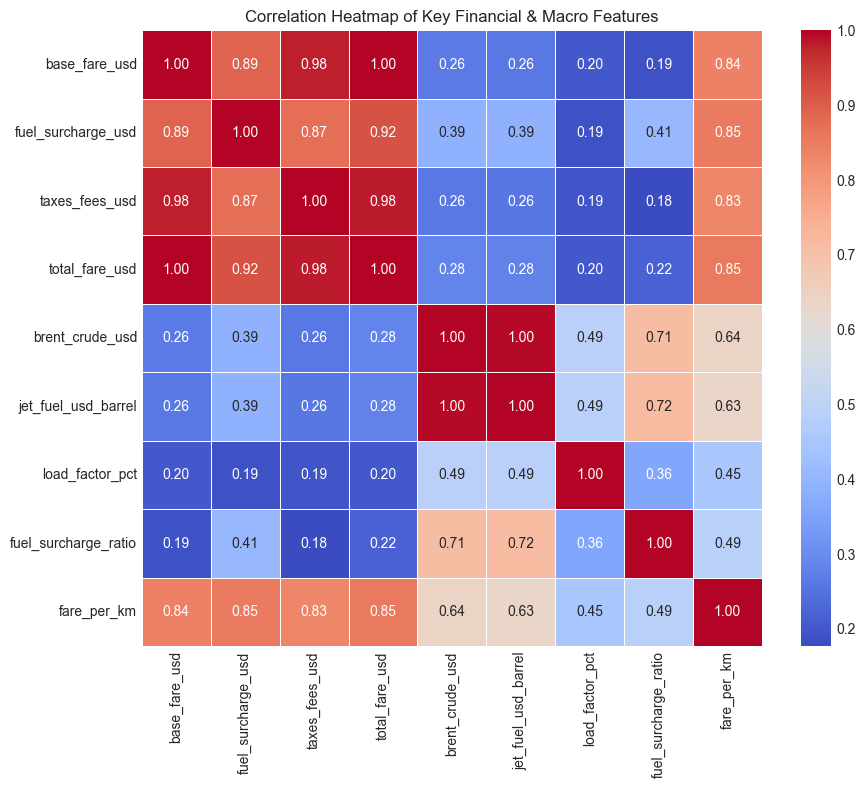

In [3]:
numeric_cols = ['base_fare_usd', 'fuel_surcharge_usd', 'taxes_fees_usd', 'total_fare_usd', 
                'brent_crude_usd', 'jet_fuel_usd_barrel', 'load_factor_pct', 'fuel_surcharge_ratio', 'fare_per_km']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Key Financial & Macro Features')
plt.show()

## 3. Categorical & Cohort Breakdowns
Comparing how different types of airlines and routes absorb or pass on fuel costs.

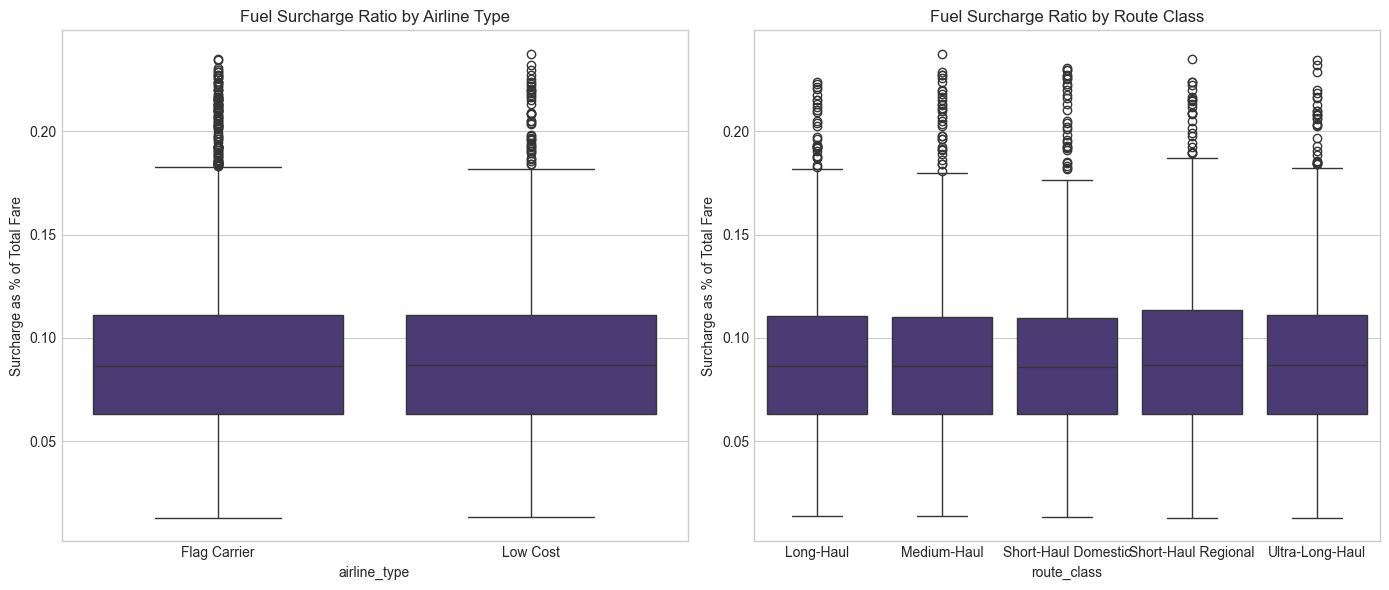

In [4]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.boxplot(x='airline_type', y='fuel_surcharge_ratio', data=df)
plt.title('Fuel Surcharge Ratio by Airline Type')
plt.ylabel('Surcharge as % of Total Fare')

plt.subplot(1, 2, 2)
sns.boxplot(x='route_class', y='fuel_surcharge_ratio', data=df)
plt.title('Fuel Surcharge Ratio by Route Class')
plt.ylabel('Surcharge as % of Total Fare')

plt.tight_layout()
plt.show()

## 4. Anatomy of a Ticket Price (Composition Analysis)
Breaking down the components of a ticket price over time.

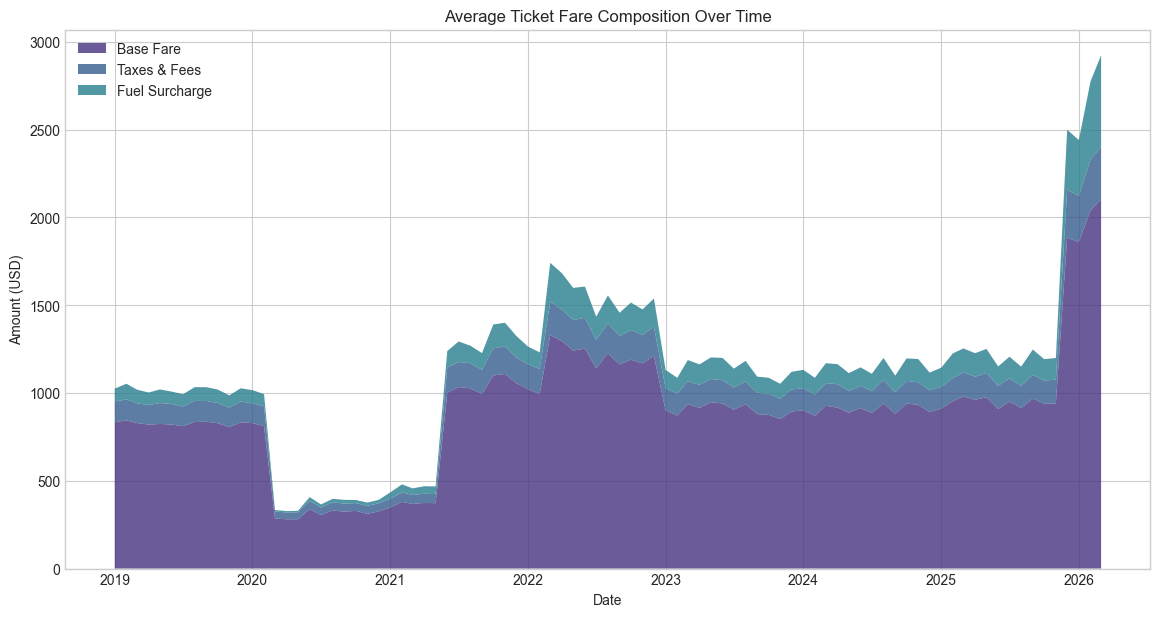

In [5]:
composition = df.groupby('month')[['base_fare_usd', 'fuel_surcharge_usd', 'taxes_fees_usd']].mean().reset_index()

plt.figure(figsize=(14, 7))
plt.stackplot(composition['month'], 
              composition['base_fare_usd'], 
              composition['taxes_fees_usd'],
              composition['fuel_surcharge_usd'],
              labels=['Base Fare', 'Taxes & Fees', 'Fuel Surcharge'],
              alpha=0.8)

plt.legend(loc='upper left')
plt.title('Average Ticket Fare Composition Over Time')
plt.xlabel('Date')
plt.ylabel('Amount (USD)')
plt.show()

## 5. Outlier Investigation
Looking at the extreme fare periods flagged during the cleaning phase.

Total extreme fare records: 287


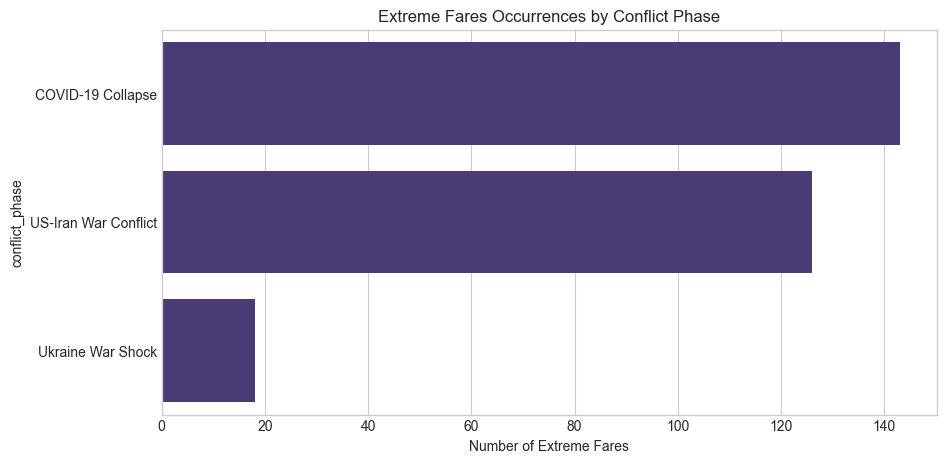

In [6]:
extreme_fares = df[df['is_extreme_fare'] == True]

print(f"Total extreme fare records: {len(extreme_fares)}")

plt.figure(figsize=(10, 5))
sns.countplot(y='conflict_phase', data=extreme_fares, order=extreme_fares['conflict_phase'].value_counts().index)
plt.title('Extreme Fares Occurrences by Conflict Phase')
plt.xlabel('Number of Extreme Fares')
plt.show()